# TVAM AID: Threshold Sweep Demonstration

## 1. Problem Definition

The lower and upper dose thresholds used by the TVAM AID penalty formulations strongly influence the characteristics of the achieved dose field. Rather than treating these thresholds as fixed inputs, they can therefore be considered design parameters of the illumination-planning problem.

This notebook systematically varies the lower and upper thresholds over a prescribed parameter space. For each valid threshold pair, an illumination plan is optimised and its achieved dose field is evaluated using:

- Process Window (PW),
- In-Part Dose-Range (IPDR),
- Voxel Error Rate (VER).

The resulting metric maps reveal how threshold selection influences optimisation performance and allow threshold pairs with desirable dose-field characteristics to be identified.

Note: for the geometries tested in the publication, selection of the best threshold pair from the parameter sweep was done by searching the metrics map for maximum PW whilst excluding threshold pairs that lead to a maximum achieved dose value greater than 1. This method of best threshold selection is used in this notebook.

## 2. Configuration

In [1]:
from tvam_aid import RunConfig, Thresholds, loadTargetGeometry, showTarget, \
    optimisation, nonNegativityConstraint, runOptimisation, \
    printMetrics, plotAchievedDose2D, plotHistogram, \
    plotPWSweep, plotIPDRSweep, plotVERSweep
from tvam_aid.penalties import L2N, OSP, OSPW
from tvam_aid.operators import createLinearOperator
from tvam_aid.callbacks import RecordMetrics, Progress
from tqdm.auto import tqdm
import numpy as np

In [2]:
# select the target geometry
pathToTarget = '../targets/DTULogo.npy'

# select which approach to use
approach = OSPW(0.0)

# define settings for the runs
config = RunConfig(
    device = 'gpu',
    numIters = 1000,
    angles = np.linspace(0, 360, 360*4, endpoint=False)
)

# define which callbacks to use in the optimisation
metrics = RecordMetrics()

## 3. Load Target Geometry and Construct the TVAM Operator

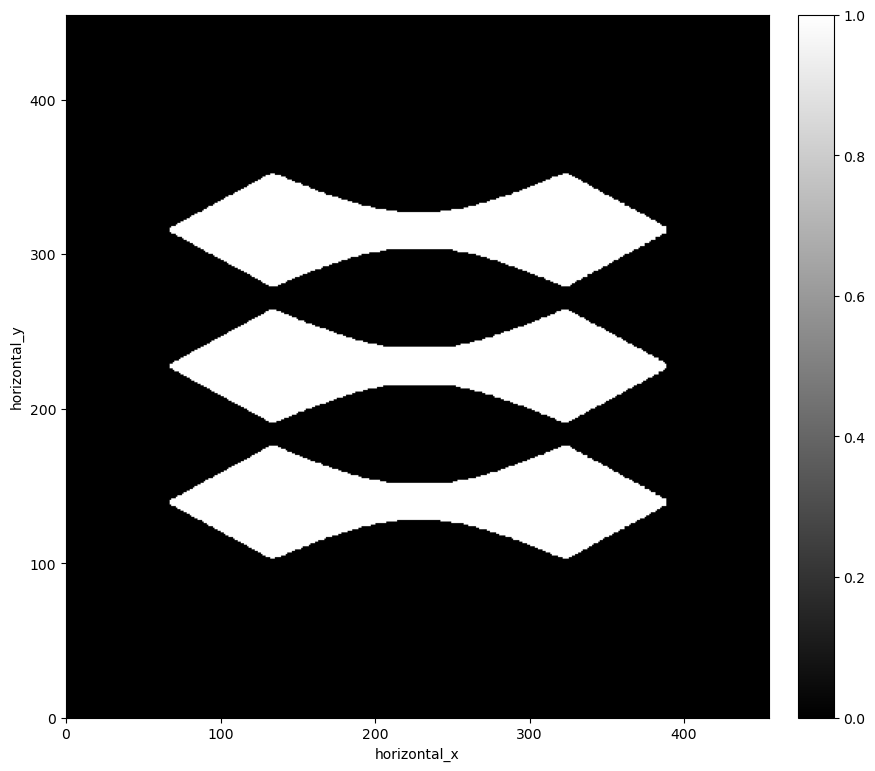

In [3]:
# load target geometry
target = loadTargetGeometry(pathToTarget)
showTarget(target)

# construct the TVAM operator
tvamOperator = createLinearOperator(target, config)

## 4. Define Combinations of Threshold Values

In [4]:
# define threshold values to investigate
thresholdValues = np.linspace(0.0, 1.0, num=26, endpoint=True)

# define the combinations of upper and lower thresholds
thresholdPairs = [
    (i, j, Thresholds(lower=lower, upper=upper))
    for i, lower in enumerate(thresholdValues)
    for j, upper in enumerate(thresholdValues)
    if (lower < upper) and (lower < 1.0) and (upper > 0.0)
]

## 5. Run Threshold Sweep

In [5]:
maxDoseAllowed = 1.0

IPDR = np.full((len(thresholdValues), len(thresholdValues)), np.nan)
PW = np.full_like(IPDR, np.nan)
VER = np.full_like(IPDR, np.nan)
maxDoseWithinLimit = np.zeros_like(IPDR, dtype=bool)

for i, j, thresholds in tqdm(thresholdPairs, total=len(thresholdPairs), desc='Threshold sweep'):
    # define the optimisation problem
    objective = approach.build(tvamOperator, target, thresholds)
    constraint = nonNegativityConstraint()

    # solve the optimisation
    metricsCallback = metrics.build(target, thresholds, tvamOperator)
    callbacks = [metricsCallback]
    illuminationPlan, achievedDose = runOptimisation(objective, constraint, target, tvamOperator, config, callbacks)
    
    # record final iteration metrics
    IPDR[i, j] = metricsCallback.IPDR[-1]
    PW[i, j] = metricsCallback.PW[-1]
    VER[i, j] = metricsCallback.VER[-1]

    # record if max achieved dose is within the given limit
    maxDoseWithinLimit[i, j] = np.amax(achievedDose.array) <= maxDoseAllowed

Threshold sweep:   0%|          | 0/325 [00:00<?, ?it/s]

## 6. Visualise Metric Maps

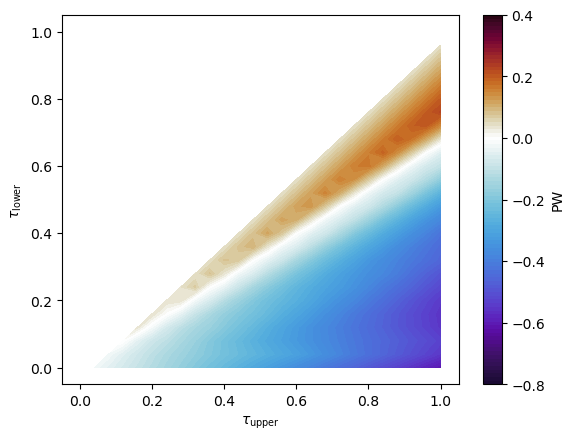

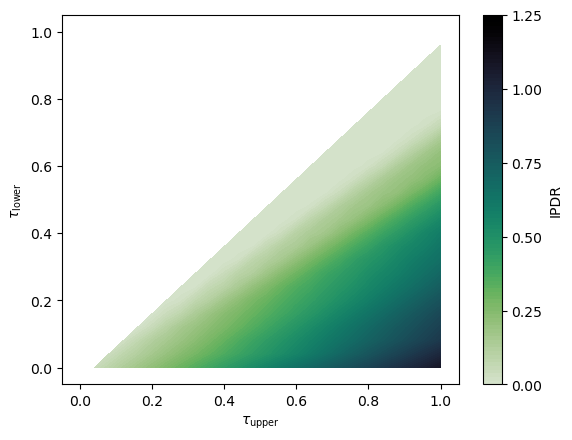

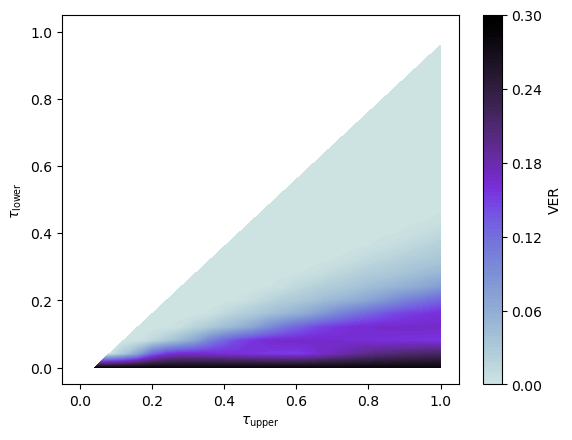

In [8]:
fig1, ax1 = plotPWSweep(PW, thresholdValues)
fig2, ax2 = plotIPDRSweep(IPDR, thresholdValues)
fig3, ax3 = plotVERSweep(VER, thresholdValues)

## 7. Identify the Best Threshold Pair

Best threshold pair: lower = 0.72, upper = 0.96
PW = 0.20009
Maximum achieved dose = 1.00000


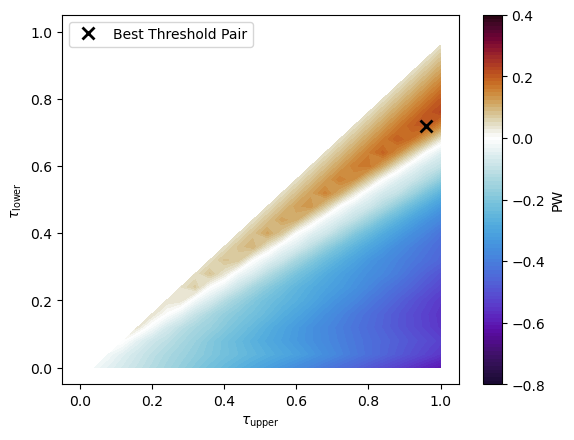

In [9]:
if not np.any(maxDoseWithinLimit):
    raise ValueError('No threshold pair satisfies the maximum dose constraint.')

# exclude threshold pairs with maximum achieved dose above the allowed limit
validPW = np.where(maxDoseWithinLimit, PW, np.nan)

# identify the threshold pair with maximum PW
bestIndex = np.nanargmax(validPW)
bestI, bestJ = np.unravel_index(bestIndex, PW.shape)
bestPW = PW[bestI, bestJ]
bestThresholds = Thresholds(lower=thresholdValues[bestI], upper=thresholdValues[bestJ])

# display result
print('Best threshold pair: lower = {:.2f}, upper = {:.2f}'.format(bestThresholds.lower, bestThresholds.upper))
print('PW = {:.5f}'.format(bestPW))
print('Maximum achieved dose = {:.5f}'.format(maxDoseAllowed))

# show location of best threshold pair on PW colour map
fig, ax = plotPWSweep(PW, thresholdValues)
ax.plot(bestThresholds.upper, bestThresholds.lower, 'xk', markersize=8, markeredgewidth=2, label='Best Threshold Pair')
_ = ax.legend(loc='upper left')

## 8. Visualise the Achieved Dose of the Best Threshold Pair


=== METRICS ===
IPDR  ¦ 0.02384
PW    ¦ 0.19827
VER   ¦ 0.00000


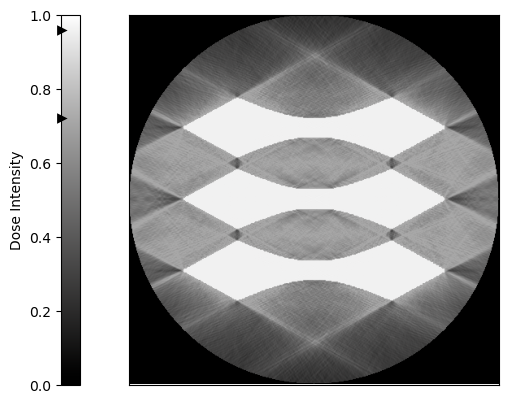

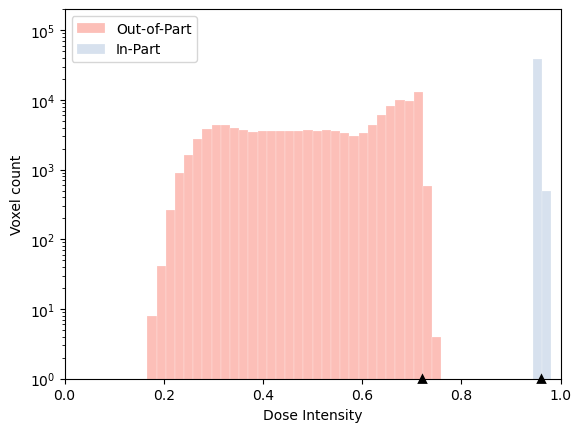

In [14]:
# define the optimisation problem
objective = approach.build(tvamOperator, target, bestThresholds)
constraint = nonNegativityConstraint()

# solve the optimisation
metricsCallback = metrics.build(target, bestThresholds, tvamOperator)
# progressCallback = progress.build()
callbacks = [metricsCallback]
illuminationPlan, achievedDose = runOptimisation(objective, constraint, target, tvamOperator, config, callbacks)

# display output
printMetrics(metricsCallback)
fig1, ax1 = plotAchievedDose2D(achievedDose, target, bestThresholds)
fig2, ax2 = plotHistogram(achievedDose, target, bestThresholds)